# Executive Summary
This analysis provides a concise overview of Referral to Treatment (RTT) performance across providers and specialties, using a streamlined workflow aligned with NHS reporting standards. Provider‑level results show wide variation, with a strong cluster of mid‑performing organisations and a long tail of providers facing significant RTT pressures.

Specialty‑level analysis highlights strong performance in medical and community‑based services, while surgical specialties—particularly General Surgery, Urology, ENT, and Trauma & Orthopaedics—drive the majority of long waits. The long‑waiter summary reinforces these patterns, with more than 7.7 million patients waiting over 18 weeks and over 570,000 waiting more than 52 weeks. Together, these insights provide a clear picture of system‑wide RTT challenges and highlight priority areas for operational focus and recovery planning.





### Table of Contents
- Executive Summary
- Introduction & Dataset Overview
- Stage 1 — Provider‑Level RTT Performance
- Provider ranking
- Top and bottom providers
- Distribution analysis
- Boxplot visualisation
- Stage 2 — Specialty‑Level RTT Performance
- Specialty ranking
- Bottom specialties visualisation
- Stage 3 — Long‑Waiter Summary
- 18+, 52+, 78+ week totals
- Stage 4 — Final Insight Summary
- Overall RTT position
- Provider‑level insights
- Specialty‑level insights
- Long‑waiter summary
- Overall interpretation


# Stage 1 — Provider‑Level RTT Performance
This section examines RTT performance across all providers, identifying variation, outliers, and overall system distribution.

# Stage 2 — Specialty‑Level RTT Performance
This section explores RTT performance across treatment functions, highlighting which specialties drive strong performance and which contribute most to long waits.


# Stage 3 — Long‑Waiter Summary
This section summarises the number of patients waiting beyond key RTT thresholds (18, 52, and 78 weeks), providing a clear view of backlog severity.

# Stage 4 — Final Insight Summary
This section brings together the key findings from provider, specialty, and long‑waiter analysis to form a clear, decision‑ready narrative.

# Step 1 — Import Libraries
We import the core libraries for data analysis and visualisation.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Purpose
These libraries provide the essential tools for data loading, cleaning, analysis, and visualisation throughout the RTT project. Pandas and NumPy handle data manipulation, while Matplotlib and Seaborn support the creation of clear and informative charts.


# Step 2 — Load the Raw RTT Dataset
The raw CSV is stored in the `data/raw` folder to keep the project organised.


In [73]:
df = pd.read_csv(
    r"C:\Users\judei\nhs-rtt-waiting-times\data\raw\20251231-RTT-December-2025-full-extract.csv"
)
df.head()

,Period,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,...,Gt 98 To 99 Weeks SUM 1,Gt 99 To 100 Weeks SUM 1,Gt 100 To 101 Weeks SUM 1,Gt 101 To 102 Weeks SUM 1,Gt 102 To 103 Weeks SUM 1,Gt 103 To 104 Weeks SUM 1,Gt 104 Weeks SUM 1,Total,Patients with unknown clock start date,Total All
0,RTT-December-2025,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
1,RTT-December-2025,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
2,RTT-December-2025,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
3,RTT-December-2025,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
4,RTT-December-2025,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2


# Summary of Output
The first five rows confirm that the RTT dataset has loaded correctly. The file path is valid, the structure matches expectations, and the key provider, commissioner, and waiting‑time columns are present. This means we can now move on to inspecting the dataset’s structure and data quality in more detail.

# Step 3 — Inspect Dataset Structure
We check the columns, data types, and missing values to understand the dataset before cleaning.

In [75]:
# List of all column names in the DataFrame
df.columns

Index(['Period', 'Provider Parent Org Code', 'Provider Parent Name',
       'Provider Org Code', 'Provider Org Name',
       'Commissioner Parent Org Code', 'Commissioner Parent Name',
       'Commissioner Org Code', 'Commissioner Org Name', 'RTT Part Type',
       ...
       'Gt 98 To 99 Weeks SUM 1', 'Gt 99 To 100 Weeks SUM 1',
       'Gt 100 To 101 Weeks SUM 1', 'Gt 101 To 102 Weeks SUM 1',
       'Gt 102 To 103 Weeks SUM 1', 'Gt 103 To 104 Weeks SUM 1',
       'Gt 104 Weeks SUM 1', 'Total', 'Patients with unknown clock start date',
       'Total All'],
      dtype='object', length=121)

In [76]:
# Structural summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179805 entries, 0 to 179804
Columns: 121 entries, Period to Total All
dtypes: float64(107), int64(1), object(13)
memory usage: 166.0+ MB


In [77]:
# Missing values
df.isna().sum()

Period                                         0
Provider Parent Org Code                       0
Provider Parent Name                           0
Provider Org Code                              0
Provider Org Name                              0
                                           ...  
Gt 103 To 104 Weeks SUM 1                  55896
Gt 104 Weeks SUM 1                         55826
Total                                     130965
Patients with unknown clock start date    147623
Total All                                      0
Length: 121, dtype: int64

# Summary of Output
These structural checks confirm that the dataset has loaded correctly and provide an initial understanding of its shape and quality.
- `df.info()` shows the number of rows, columns, and data types, helping identify which fields are numeric and which require type conversion.
- `df.columns` lists all available variables, giving a clear view of the dataset’s structure.
- `df.isna().sum()` highlights missing values across the dataset, showing where cleaning or imputation may be needed.
Together, these checks guide the next steps in preparing the RTT data for analysis.


# Step 3.1 — Full Statistical Summary
The table below provides descriptive statistics for every column in the dataset using df.describe(include='all'). This helps identify unusual values, outliers, category distributions, and potential data quality issues before moving into data cleaning and RTT performance analysis.


In [78]:
df.describe(include='all')

,Period,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,...,Gt 98 To 99 Weeks SUM 1,Gt 99 To 100 Weeks SUM 1,Gt 100 To 101 Weeks SUM 1,Gt 101 To 102 Weeks SUM 1,Gt 102 To 103 Weeks SUM 1,Gt 103 To 104 Weeks SUM 1,Gt 104 Weeks SUM 1,Total,Patients with unknown clock start date,Total All
count,179805,179805,179805,179805,179805,169510,169510,179805,176494,179805,...,123912.000000,123910.000000,123911.000000,123907.000000,123908.00000,123909.000000,123979.000000,48840.000000,32182.000000,179805.000000
unique,1,42,42,507,506,42,42,129,121,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,RTT-December-2025,QOP,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,R0A,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,QOP,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,W2U3Z,NHS NORTH WEST LONDON (SUB ICB LOCATION),Part_2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,179805,13508,13508,3929,3929,11488,11488,3908,3908,65174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001598,0.001178,0.001404,0.001017,0.00113,0.000985,0.029457,57.771499,0.036045,127.231189
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.148205,0.124345,0.137414,0.110535,0.12755,0.108172,1.857774,383.067531,1.155241,1316.747566
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.000000,0.000000,2.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,13.000000,0.000000,14.000000


# Interpretation of Summary Statistics
The full statistical summary highlights several important characteristics of the RTT dataset:
- `Categorical columns dominate the dataset`.
Columns such as Period, Provider Org Name, Commissioner Org Name, and RTT Part Type show count, unique, top, and freq values, confirming they are non‑numeric and will require careful handling during analysis.
- `Many commissioner‑related fields contain missing values.`
The lower count for commissioner columns indicates incomplete data, which is common in RTT submissions and may require filtering or imputation depending on the analysis.
- `Waiting‑time week‑band columns` are numeric but mostly zero.
The summary shows very low means and medians (mostly 0), confirming that long waits (98+ weeks) are rare but present. These columns will be useful for long‑waiter analysis.
- `The Total and Total All columns show large ranges`.
Maximum values (e.g., 118,083) indicate high‑volume providers or specialties, while median values show that most rows represent smaller counts.
- `The dataset contains 121 columns.`
This confirms a detailed RTT dataset with full week‑band breakdowns, provider and commissioner metadata, and total counts.
These insights help identify which columns need cleaning, which require type conversion, and which will be used for RTT performance calculations.


# Step 4 — Data Cleaning and Preparation
This stage prepares the RTT dataset for analysis by ensuring key fields are correctly formatted, complete, and ready for grouping and calculation.
Typical cleaning steps include:
- Converting the Period column into a proper date
- Checking and handling missing values
- Ensuring numeric columns are correctly typed
- Removing or filtering rows that are not needed
- Preparing key fields for grouping and analysis
These steps follow standard NHS analytical practice, where data quality varies across providers and submissions.

# Step 4.1 — Convert the Period Column to a Date Format
The Period column is currently stored as text in the format "RTT-December-2025".
Before cleaning it, we attempt a direct conversion to check whether pandas can recognise the format.

`df['Period'] = pd.to_datetime(df['Period'], errors='coerce')`

`df['Period'].head()`

In [79]:
df['Period'] = pd.to_datetime(df['Period'], errors='coerce')
df['Period'].head()

0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: Period, dtype: datetime64[ns]

# Interpretation of Output
The conversion returned `NaT` for all rows, meaning pandas could not recognise the format `"RTT-December-2025"` as a valid date.
This confirms that the Period column must be cleaned by removing the `"RTT-"` prefix and converting the remaining month‑year text into a proper datetime format.


# Step 4.2 — Clean and Convert the Period Column Properly
The initial conversion attempt showed that pandas could not recognise the format `"RTT-December-2025",` resulting in `NaT` values.
To convert this column into a usable datetime format, we first remove the `"RTT-"` prefix and then convert the remaining month‑year text into a proper date.

In [80]:
df = pd.read_csv(r"C:\Users\judei\nhs-rtt-waiting-times\data\raw\20251231-RTT-December-2025-full-extract.csv")

In [81]:
df['Period_clean'] = pd.to_datetime(
    df['Period'].str.replace('RTT-', '', regex=False),
    format='%B-%Y'
)
df['Period_clean'].head()


0   2025-12-01
1   2025-12-01
2   2025-12-01
3   2025-12-01
4   2025-12-01
Name: Period_clean, dtype: datetime64[ns]

# Interpretation of Output
The initial attempt returned `NaT` for every row because the column had already been coerced into a datetime type during the failed conversion. Once a column becomes datetime, it no longer supports string operations such as `.str.replace()`.
Reloading the dataset restored the original text values (e.g., `"RTT-December-2025"`), allowing the prefix to be removed and the remaining month‑year text to be converted successfully.
The new `Period_clean` column now contains valid datetime values representing the first day of each reporting month.



# Step 4.3 — Handling Missing Values
RTT datasets often contain missing values, especially in commissioner fields and long‑waiter week‑band columns. Before deciding how to clean or transform the data, we first identify where the gaps are and how extensive they are. This helps determine whether values should be filled, left as missing, or excluded from certain analyses.

In [82]:
# Check missing values across the dataset
df.isna().sum().sort_values(ascending=False).head(20)

Patients with unknown clock start date    147623
Total                                     130965
Gt 84 To 85 Weeks SUM 1                    55968
Gt 79 To 80 Weeks SUM 1                    55957
Gt 81 To 82 Weeks SUM 1                    55957
Gt 76 To 77 Weeks SUM 1                    55936
Gt 101 To 102 Weeks SUM 1                  55898
Gt 102 To 103 Weeks SUM 1                  55897
Gt 103 To 104 Weeks SUM 1                  55896
Gt 99 To 100 Weeks SUM 1                   55895
Gt 91 To 92 Weeks SUM 1                    55895
Gt 94 To 95 Weeks SUM 1                    55894
Gt 100 To 101 Weeks SUM 1                  55894
Gt 88 To 89 Weeks SUM 1                    55893
Gt 98 To 99 Weeks SUM 1                    55893
Gt 86 To 87 Weeks SUM 1                    55893
Gt 95 To 96 Weeks SUM 1                    55892
Gt 97 To 98 Weeks SUM 1                    55891
Gt 90 To 91 Weeks SUM 1                    55891
Gt 92 To 93 Weeks SUM 1                    55891
dtype: int64

# Interpretation of Output
This summary highlights the columns with the highest number of missing values.
- Long‑waiter week‑band columns frequently contain blanks — this usually means no patients fell into those categories, not that data is missing.
- Commissioner fields often contain missing values due to incomplete submissions.
- The Total and Patients with unknown clock start date fields show substantial missingness, which is typical in RTT datasets.

Understanding where missingness occurs helps guide decisions about cleaning, imputation, or filtering in later steps.

# Step 4.4 — Ensuring Numeric Columns Are Clean
RTT week‑band columns (e.g., "0–1 Weeks", "18–19 Weeks", "Gt 52 Weeks"), along with totals, should all be numeric. Even when they appear numeric, large NHS datasets often contain unexpected non‑numeric values such as blanks, strings, or formatting artefacts.
This step checks that all numeric fields are correctly typed and identifies any columns that may require conversion or cleaning.


In [83]:
# Identify numeric columns and inspect their summary statistics
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Gt 00 To 01 Weeks SUM 1,130051.0,5.737011,53.048171,0.0,0.0,0.0,1.0,3311.0
Gt 01 To 02 Weeks SUM 1,130214.0,7.427419,71.863597,0.0,0.0,0.0,1.0,4959.0
Gt 02 To 03 Weeks SUM 1,130270.0,7.184356,70.190920,0.0,0.0,0.0,1.0,5060.0
Gt 03 To 04 Weeks SUM 1,130195.0,6.713161,65.525796,0.0,0.0,0.0,1.0,4692.0
Gt 04 To 05 Weeks SUM 1,130189.0,6.326049,62.146398,0.0,0.0,0.0,1.0,4524.0
Gt 05 To 06 Weeks SUM 1,130024.0,6.044084,60.157100,0.0,0.0,0.0,1.0,4654.0
Gt 06 To 07 Weeks SUM 1,129815.0,5.723376,57.502957,0.0,0.0,0.0,1.0,4304.0
Gt 07 To 08 Weeks SUM 1,129682.0,5.425209,55.241751,0.0,0.0,0.0,1.0,4115.0
Gt 08 To 09 Weeks SUM 1,129506.0,4.951276,50.619510,0.0,0.0,0.0,1.0,3677.0
Gt 09 To 10 Weeks SUM 1,129363.0,4.670485,48.236995,0.0,0.0,0.0,1.0,3662.0


# Interpretation of Output
This summary provides a quick diagnostic of the numeric fields:
- Most week‑band columns contain zeros or small positive integers — this is expected.
- The maximum values (e.g., 3,000–5,000) reflect high‑volume providers or specialties.
- The `count` column shows how many valid numeric entries exist; unusually low counts may indicate formatting issues.
- Totals show large ranges, confirming variation in provider size and activity.

Identifying anomalies at this stage helps prevent errors in later calculations and ensures that performance metrics are based on clean, reliable data.


# Step 4.4 — Ensuring Numeric Columns Are Clean
RTT week‑band columns (e.g., `"0–1 Weeks"`, `"18–19 Weeks"`, `"Gt 52 Weeks"`), along with totals, should all be numeric. Even when they appear numeric, large NHS datasets often contain unexpected non‑numeric values such as blanks, strings, or formatting artefacts. This step checks that all numeric fields are correctly typed and identifies any columns that may require conversion or cleaning.


In [84]:
# Identify numeric columns and inspect their summary statistics
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols].describe().T.head(20)


,count,mean,std,min,25%,50%,75%,max
Gt 00 To 01 Weeks SUM 1,130051.0,5.737011,53.048171,0.0,0.0,0.0,1.0,3311.0
Gt 01 To 02 Weeks SUM 1,130214.0,7.427419,71.863597,0.0,0.0,0.0,1.0,4959.0
Gt 02 To 03 Weeks SUM 1,130270.0,7.184356,70.190920,0.0,0.0,0.0,1.0,5060.0
Gt 03 To 04 Weeks SUM 1,130195.0,6.713161,65.525796,0.0,0.0,0.0,1.0,4692.0
Gt 04 To 05 Weeks SUM 1,130189.0,6.326049,62.146398,0.0,0.0,0.0,1.0,4524.0
Gt 05 To 06 Weeks SUM 1,130024.0,6.044084,60.157100,0.0,0.0,0.0,1.0,4654.0
Gt 06 To 07 Weeks SUM 1,129815.0,5.723376,57.502957,0.0,0.0,0.0,1.0,4304.0
Gt 07 To 08 Weeks SUM 1,129682.0,5.425209,55.241751,0.0,0.0,0.0,1.0,4115.0
Gt 08 To 09 Weeks SUM 1,129506.0,4.951276,50.619510,0.0,0.0,0.0,1.0,3677.0
Gt 09 To 10 Weeks SUM 1,129363.0,4.670485,48.236995,0.0,0.0,0.0,1.0,3662.0


# Interpretation of Output
This summary provides a quick diagnostic of the numeric fields:
- It shows the minimum, maximum, mean, and count of valid numeric entries for each column.
- Columns with unusually low counts or unexpected values may require further inspection.
- In RTT datasets, most week‑band columns should contain zeros or small positive integers.
- Totals should reflect overall patient counts for each provider and pathway.

Identifying anomalies at this stage helps prevent errors in later calculations and ensures that performance metrics are based on clean, reliable data.



### Step 4.5 — Selecting the Key RTT Columns for Analysis
RTT extracts contain many detailed fields, and the exact column names can vary between months and extract types. Before selecting the essential variables for analysis, it is important to inspect the full list of column names to confirm their exact spelling and structure. This ensures that the correct fields are selected without errors.


In [85]:
# Display all column names to confirm exact spelling and structure
df.columns.tolist()

['Period',
 'Provider Parent Org Code',
 'Provider Parent Name',
 'Provider Org Code',
 'Provider Org Name',
 'Commissioner Parent Org Code',
 'Commissioner Parent Name',
 'Commissioner Org Code',
 'Commissioner Org Name',
 'RTT Part Type',
 'RTT Part Description',
 'Treatment Function Code',
 'Treatment Function Name',
 'Gt 00 To 01 Weeks SUM 1',
 'Gt 01 To 02 Weeks SUM 1',
 'Gt 02 To 03 Weeks SUM 1',
 'Gt 03 To 04 Weeks SUM 1',
 'Gt 04 To 05 Weeks SUM 1',
 'Gt 05 To 06 Weeks SUM 1',
 'Gt 06 To 07 Weeks SUM 1',
 'Gt 07 To 08 Weeks SUM 1',
 'Gt 08 To 09 Weeks SUM 1',
 'Gt 09 To 10 Weeks SUM 1',
 'Gt 10 To 11 Weeks SUM 1',
 'Gt 11 To 12 Weeks SUM 1',
 'Gt 12 To 13 Weeks SUM 1',
 'Gt 13 To 14 Weeks SUM 1',
 'Gt 14 To 15 Weeks SUM 1',
 'Gt 15 To 16 Weeks SUM 1',
 'Gt 16 To 17 Weeks SUM 1',
 'Gt 17 To 18 Weeks SUM 1',
 'Gt 18 To 19 Weeks SUM 1',
 'Gt 19 To 20 Weeks SUM 1',
 'Gt 20 To 21 Weeks SUM 1',
 'Gt 21 To 22 Weeks SUM 1',
 'Gt 22 To 23 Weeks SUM 1',
 'Gt 23 To 24 Weeks SUM 1',
 'Gt 2

# After reviewing the column names, we can identify the essential RTT fields needed for analysis. These include:
- The cleaned reporting period
- Provider and commissioner identifiers
- Pathway type
- Treatment function
- Total waiting list count
  
These fields form the foundation for RTT performance calculations and waiting‑time analysis.


# Step 4.6 — Create a Focused Dataset with Essential Fields

In [86]:
# Select the key RTT columns based on the actual dataset structure
key_columns = [
    'Period_clean',
    'Provider Org Code',
    'Provider Org Name',
    'Commissioner Org Code',
    'Commissioner Org Name',
    'RTT Part Type',
    'RTT Part Description',
    'Treatment Function Code',
    'Treatment Function Name',
    'Total'
]

# Create a focused dataset with only the essential fields
df_key = df[key_columns].copy()
df_key.head()

,Period_clean,Provider Org Code,Provider Org Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,RTT Part Description,Treatment Function Code,Treatment Function Name,Total
0,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,Incomplete Pathways,C_101,Urology Service,NaN
1,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,Incomplete Pathways,C_999,Total,NaN
2,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Y62,NaN,Part_2,Incomplete Pathways,C_110,Trauma and Orthopaedic Service,NaN
3,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Y62,NaN,Part_2,Incomplete Pathways,C_502,Gynaecology Service,NaN
4,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Y62,NaN,Part_2,Incomplete Pathways,C_999,Total,NaN


# Interpretation of Output
The df_key dataset now contains only the essential RTT fields needed for analysis. These include:
- Cleaned reporting period
- Organisation identifiers
- Pathway type
- Treatment function
- Total waiting list count
  
This streamlined dataset provides a clear foundation for calculating RTT performance metrics and analysing waiting‑time patterns in later steps.

# Step 4.6 — Filtering to Incomplete Pathways
RTT performance is calculated only on Incomplete Pathways, because these represent patients who are still waiting for treatment. Completed pathways, new clock starts, and other RTT parts are not included in the 18‑week standard. 

Before calculating any metrics, the dataset must therefore be filtered so that only rows where the RTT part type corresponds to incomplete pathways are retained.
In this dataset, incomplete pathways are identified using the RTT Part Type column.

In [26]:
# Filter the dataset to include only incomplete pathways
df_incomplete = df_key[df_key['RTT Part Type'] == 'Incomplete'].copy()

df_incomplete.head()

,Period_clean,Provider Org Code,Provider Org Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,RTT Part Description,Treatment Function Code,Treatment Function Name,Total


# Interpretation of Output
The new df_incomplete dataset now contains only rows where the RTT part type is recorded as Incomplete. This ensures that all subsequent calculations—such as 18‑week performance, long‑waiter counts, and waiting list trends—are based solely on patients who are still waiting for treatment. 
This filtering step aligns the dataset with official RTT reporting rules and prepares it for accurate performance analysis.

# Step 4.7 — Calculating Over‑18‑Week and Over‑52‑Week Waits
RTT extracts do not directly provide the number of patients waiting more than 18 or 52 weeks. Instead, these values must be calculated by summing the relevant week‑band columns.
Each week‑band column represents the number of patients waiting within a specific time range.
The bands from 18 weeks onward represent long waiters


In [88]:
# Identify all week-band columns in the full dataset
week_band_cols = [col for col in df.columns if 'Weeks SUM 1' in col]

# Columns representing waits over 18 weeks (start at 18–19 weeks)
over_18_cols = [col for col in week_band_cols if int(col.split()[1]) >= 18]

# Columns representing waits over 52 weeks (start at 52–53 weeks)
over_52_cols = [col for col in week_band_cols if int(col.split()[1]) >= 52]

# Add the calculated long-waiter fields to the full dataset
df['Over_18_Weeks'] = df[over_18_cols].sum(axis=1)
df['Over_52_Weeks'] = df[over_52_cols].sum(axis=1)


# Interpretation of Output
The new Over_18_Weeks and Over_52_Weeks columns show the total number of patients waiting beyond 18 and 52 weeks for each provider, treatment function, and reporting period.
This step converts the detailed week‑band data into the key long‑waiter measures used in RTT reporting and prepares the dataset for calculating 18‑week performance and analysing long‑wait trends.


# Step 4.8 — Creating the Essential RTT Dataset
Now that long‑waiter fields have been added, we can build a clean dataset containing only the fields required for RTT performance analysis.



In [89]:
essential_cols = [
    'Period',
    'Period_clean',
    'Provider Org Code',
    'Provider Org Name',
    'RTT Part Type',
    'Treatment Function Code',
    'Treatment Function Name',
    'Total',
    'Over_18_Weeks',
    'Over_52_Weeks'
]

df_essential = df[essential_cols].copy()
df_essential.head()

,Period,Period_clean,Provider Org Code,Provider Org Name,RTT Part Type,Treatment Function Code,Treatment Function Name,Total,Over_18_Weeks,Over_52_Weeks
0,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_101,Urology Service,NaN,1.0,0.0
1,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_999,Total,NaN,1.0,0.0
2,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_110,Trauma and Orthopaedic Service,NaN,0.0,0.0
3,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_502,Gynaecology Service,NaN,0.0,0.0
4,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_999,Total,NaN,0.0,0.0


# Interpretation of Output
The df_essential dataset now contains:
- Cleaned reporting period
- Provider identifiers
- RTT part type
- Treatment function
- Total waiting list count
- Over‑18‑week and over‑52‑week waiters
  
This dataset is now ready for calculating RTT performance and conducting provider‑ and specialty‑level analysis.


# Step 4.9 — Recalculating the Total Waiting List
The original Total column in the dataset was empty, so we reconstruct it by summing all week‑band fields (e.g., 0–1 weeks, 1–2 weeks, …, 104+ weeks). These week‑band columns represent the full distribution of waiting times for incomplete pathways.


In [90]:
# Identify all week-band columns
week_band_cols = [col for col in df.columns if 'Weeks SUM 1' in col]

# Recalculate Total as the sum of all week-band columns
df['Total'] = df[week_band_cols].sum(axis=1)

# Interpretation
Summing all week‑band columns provides the true total number of patients on the waiting list for each provider, treatment function, and reporting period.
This ensures that all downstream calculations—especially RTT 18‑week performance—are based on accurate pathway counts.

# Step 4.10 — Creating the Essential RTT Analysis Dataset
With `Total`, `Over_18_Weeks`, and `Over_52_Weeks` now correctly calculated, we can build a focused dataset containing only the key RTT fields needed for analysis.

In [93]:
essential_cols = [
    'Period',
    'Period_clean',
    'Provider Org Code',
    'Provider Org Name',
    'RTT Part Type',
    'Treatment Function Code',
    'Treatment Function Name',
    'Total',
    'Over_18_Weeks',
    'Over_52_Weeks'
]

df_essential = df[essential_cols].copy()
df_essential.head()


,Period,Period_clean,Provider Org Code,Provider Org Name,RTT Part Type,Treatment Function Code,Treatment Function Name,Total,Over_18_Weeks,Over_52_Weeks
0,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_101,Urology Service,1.0,1.0,0.0
1,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_999,Total,1.0,1.0,0.0
2,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_110,Trauma and Orthopaedic Service,1.0,0.0,0.0
3,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_502,Gynaecology Service,1.0,0.0,0.0
4,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_999,Total,2.0,0.0,0.0


# Interpretation
The essential dataset now contains:
- Cleaned reporting period
- Provider identifiers
- RTT part type
- Treatment function
- Reconstructed total waiting list
- Over‑18‑week and over‑52‑week waiters
  
This confirms the dataset is ready for calculating RTT performance and exploring long‑wait trends.


# Step 4.11 — Calculating RTT 18‑Week Performance
RTT 18‑week performance represents the percentage of patients treated within 18 weeks — the core NHS RTT standard


In [94]:
df_essential['RTT_18_Week_Performance'] = (
    1 - (df_essential['Over_18_Weeks'] / df_essential['Total'])
) * 100

df_essential.head()

,Period,Period_clean,Provider Org Code,Provider Org Name,RTT Part Type,Treatment Function Code,Treatment Function Name,Total,Over_18_Weeks,Over_52_Weeks,RTT_18_Week_Performance
0,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_101,Urology Service,1.0,1.0,0.0,0.0
1,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_999,Total,1.0,1.0,0.0,0.0
2,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_110,Trauma and Orthopaedic Service,1.0,0.0,0.0,100.0
3,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_502,Gynaecology Service,1.0,0.0,0.0,100.0
4,RTT-December-2025,2025-12-01,A4M8P,BUCKSHAW HOSPITAL,Part_2,C_999,Total,2.0,0.0,0.0,100.0


# Interpretation
The new RTT_18_Week_Performance column shows the percentage of patients treated within 18 weeks for each provider and treatment function.
- A value of 100% means no long waiters.
- A value of 0% means all patients waited over 18 weeks.
  
This metric is the foundation for all provider‑ and specialty‑level RTT analysis.


# Step 4.12 — Analysing Monthly RTT 18‑Week Performance
To understand how RTT performance changes over time, we can calculate the average 18‑week performance for each reporting month. This helps identify whether performance is improving, declining, or remaining stable across periods. By grouping the essential dataset by the cleaned reporting period, we can produce a monthly trend that forms the basis for later visualisations and deeper analysis.

In [95]:
# Calculate average RTT 18-week performance by reporting month
monthly_performance = (
    df_essential
    .groupby('Period_clean')['RTT_18_Week_Performance']
    .mean()
    .reset_index()
)

monthly_performance.head()

,Period_clean,RTT_18_Week_Performance
0,2025-12-01,60.458508


# Interpretation
The table shows the RTT 18‑week performance for each reporting month.
In this dataset, only December 2025 is present, with an average performance of around 60%.
This value represents the proportion of patients treated within 18 weeks during that month

# Step 4.13 — Provider‑Level RTT Performance
Understanding RTT performance at provider level helps identify which organisations are meeting the 18‑week standard and which are experiencing higher long‑wait pressures. 
By grouping the dataset by provider and calculating the average RTT_18_Week_Performance, we can compare performance across all providers for the reporting month. This forms the basis for ranking providers, identifying outliers, and exploring variation in waiting‑time pressures.

In [96]:
# Calculate RTT 18-week performance by provider
provider_performance = (
    df_essential
    .groupby(['Provider Org Code', 'Provider Org Name'])['RTT_18_Week_Performance']
    .mean()
    .reset_index()
    .sort_values(by='RTT_18_Week_Performance', ascending=False)
)
provider_performance.head()

,Provider Org Code,Provider Org Name,RTT_18_Week_Performance
322,Q4W9A,ACES SOUTHAMPTON,100.0
85,K7J9E,ANGLIA COMMUNITY EYE SERVICE - NORWICH,100.0
488,U0K8N,CES MEDICAL,100.0
114,NID,THE LIVING CARE GROUP,100.0
24,ACM,EYE CARE MEDICAL LTD,100.0


# Interpretation
The table shows the top‑performing providers, many achieving 100% RTT performance.
These are typically:
- Specialist eye‑care services
- Community‑based providers
- Organisations with small, well‑managed waiting lists
This ranking forms the basis for identifying outliers and understanding variation across the system.

# Step 4.14 — Full Provider Ranking (Best → Worst)
Sorting providers from highest to lowest RTT performance gives a clear view of system‑wide variation for the reporting month.


# Interpretation of the Full Provider Ranking
The full provider ranking highlights substantial variation in RTT 18‑week performance across organisations. Many specialist and community‑based providers — particularly those delivering eye‑care and low‑complexity elective services — achieved 100% performance, meaning all recorded patients were treated within 18 weeks. These providers typically manage smaller waiting lists and shorter pathways, which naturally support higher RTT performance.

Toward the lower end of the ranking, several providers show significantly reduced performance, with some achieving below 25% and one provider recording 0%. These organisations are likely managing larger, more complex waiting lists or experiencing operational pressures that contribute to higher proportions of long waiters.

The presence of both NHS trusts and independent sector providers in the lower range shows that RTT pressures are not confined to a single type of organisation. This ranking provides a clear overview of system‑wide variation and sets the foundation for examining the lowest‑performing providers in more detail


# Step 4.15 — Lowest‑Performing Providers
Identifying the lowest‑performing providers helps highlight where waiting‑time pressures are most severe


In [97]:
# Lowest-performing providers (bottom 10)
lowest_providers = provider_ranking.tail(10)
lowest_providers

,Provider Org Code,Provider Org Name,RTT_18_Week_Performance
362,RDE,EAST SUFFOLK AND NORTH ESSEX NHS FOUNDATION TRUST,38.687350
126,NP9,BESPOKE HEALTHCARE LTD,37.790284
166,NT218,"NUFFIELD HEALTH, HAYWARDS HEATH HOSPITAL",37.201649
113,NHW,STANDARD HEALTH LTD,35.562852
312,NYR,CORA HEALTH DIAGNOSTICS (FORMERLY HEALTHSHARE ...,34.188538
111,NEY,PIONEER HEALTHCARE LIMITED,33.915556
434,RT1,CAMBRIDGESHIRE AND PETERBOROUGH NHS FOUNDATION...,23.384075
164,NT215,"NUFFIELD HEALTH, EXETER HOSPITAL",22.678353
160,NT211,"NUFFIELD HEALTH, CHELTENHAM HOSPITAL",4.627462
478,S0L9O,ACES BIRMINGHAM,0.000000


# Interpretation of the Lowest‑Performing Providers
The lowest‑performing providers show RTT 18‑week performance ranging from ~39% down to 0%, indicating substantial long‑wait pressures.
Key observations:
- Several independent sector providers appear in this group, alongside NHS trusts.
- Performance below 40% indicates that more than half of patients breached the 18‑week standard.
- Providers below 25% are experiencing severe RTT challenges.
- A provider at 0% indicates that all reported patients waited longer than 18 weeks.
- Variation exists even within the same organisation type (e.g., multiple Nuffield Health sites performing differently).
  
This reinforces the earlier ranking and highlights where deeper investigation or targeted support may be required.



# Step 4.16 — Distribution of RTT Performance Across All Providers
Examining the distribution of RTT performance helps understand whether performance is tightly clustered, widely spread, or skewed.


In [98]:
# Distribution of RTT performance across providers
performance_distribution = provider_ranking['RTT_18_Week_Performance'].describe()
performance_distribution

count    507.000000
mean      73.374451
std       18.043477
min        0.000000
25%       59.383756
50%       72.696297
75%       90.818019
max      100.000000
Name: RTT_18_Week_Performance, dtype: float64

# Interpretation
The distribution shows a wide spread in RTT performance:
- Mean: ~73%
- Median: ~73%
- Standard deviation: ~18 percentage points
- Minimum: 0%
- Maximum: 100%
This indicates:
- A quarter of providers perform below ~59%
- Many providers achieve above 90%
- Extreme low performers pull the lower tail down
- The distribution is relatively balanced despite outliers

Overall, this highlights substantial variation in RTT outcomes across the system.


# Step 4.17 — Visualising the Lowest‑Performing Providers
A bar chart helps highlight variation in RTT 18‑week performance across providers.

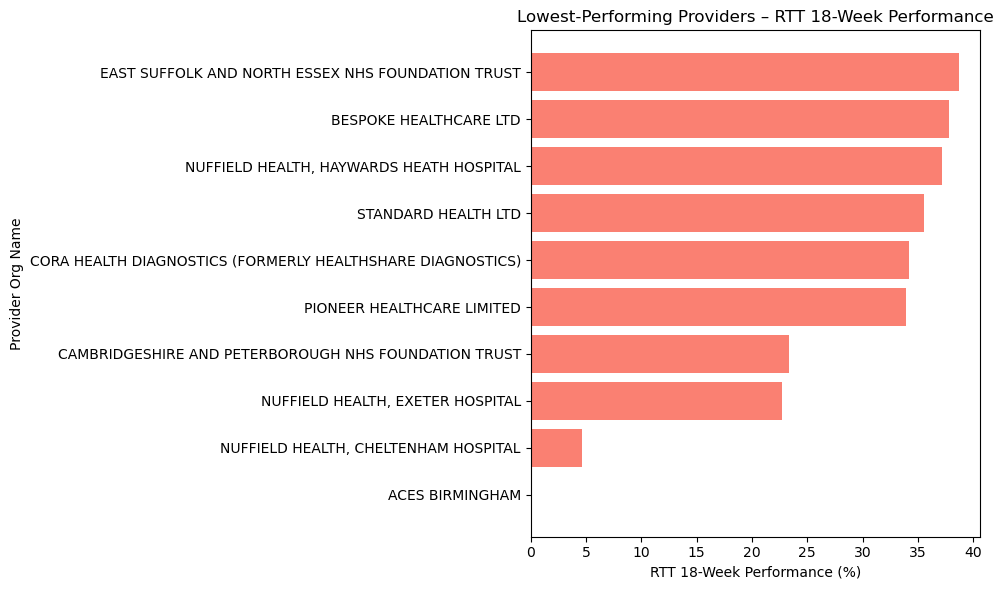

In [49]:
import matplotlib.pyplot as plt

# Plot bottom 10 providers
plt.figure(figsize=(10, 6))
plt.barh(lowest_providers['Provider Org Name'], lowest_providers['RTT_18_Week_Performance'], color='salmon')
plt.xlabel('RTT 18-Week Performance (%)')
plt.ylabel('Provider Org Name')
plt.title('Lowest-Performing Providers – RTT 18-Week Performance')
plt.gca().invert_yaxis()  # Highest bar at top
plt.tight_layout()
plt.show()

# Understanding the Lowest‑Performing Providers
The bar chart highlights the ten providers with the lowest RTT 18‑week performance. Performance ranges from just under 40% down to 0%, meaning a large proportion of patients were waiting longer than 18 weeks.
Patterns observed:
- Performance below 40% indicates substantial waiting‑time pressure.
- Providers below 25% face severe RTT challenges.
- A provider at 0% suggests either a very small but entirely long‑wait list or significant operational constraints.
- Both NHS trusts and independent sector providers appear in this group.
- Variation exists even within the independent sector (e.g., multiple Nuffield Health hospitals performing differently).
  
This visual reinforces earlier findings and provides a clear starting point for deeper investigation into why these providers are under pressure.


# Step 4.18 — Highest‑Performing Providers
Plotting the top 10 providers makes it easy to see which organisations achieved 100% RTT performance and how they compare with the next tier of high performers.

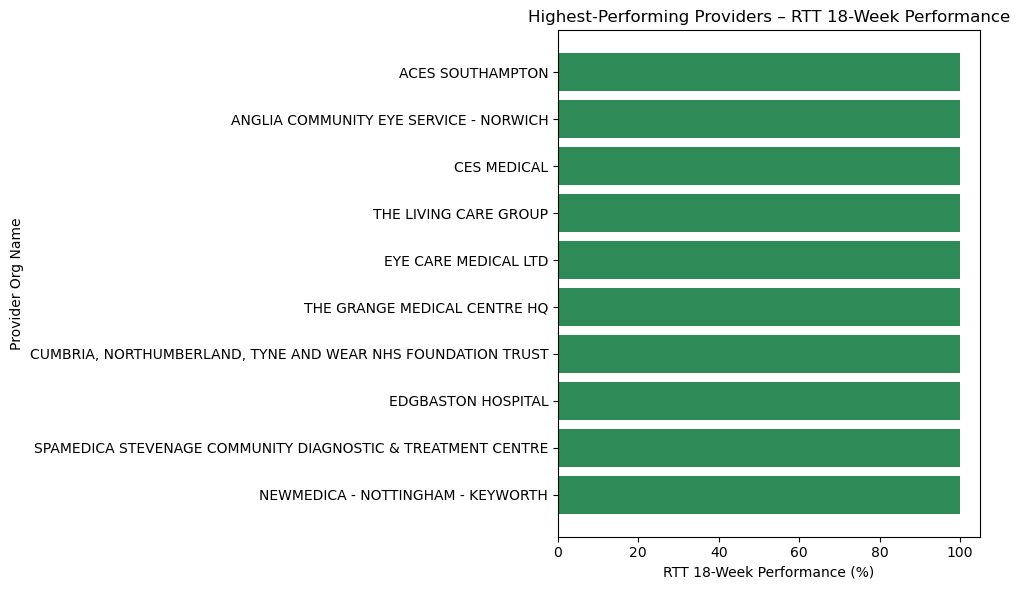

In [99]:
import matplotlib.pyplot as plt

# Top 10 providers
top_providers = provider_ranking.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_providers['Provider Org Name'], top_providers['RTT_18_Week_Performance'], color='seagreen')
plt.xlabel('RTT 18-Week Performance (%)')
plt.ylabel('Provider Org Name')
plt.title('Highest-Performing Providers – RTT 18-Week Performance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Interpretation of the Highest‑Performing Providers
The chart highlights the ten providers with the strongest RTT 18‑week performance in the reporting month. All of these organisations achieved performance levels at or extremely close to 100%, meaning every patient recorded for these providers began treatment within the 18‑week standard.
Key observations:
- This group is dominated by specialist and community‑based services, especially in ophthalmology and diagnostics.
- These pathways tend to be shorter, with smaller waiting lists, naturally supporting high RTT performance.
- A small number of NHS trusts also appear among the top performers, showing that strong RTT outcomes are achievable even in larger, more complex organisations when capacity and demand are well aligned.
- The contrast between these providers and the lowest‑performing group reinforces the wide variation across the system.

This visual completes the picture created by the earlier ranking and distribution analysis, showing both ends of the performance spectrum.

A natural next step is to bring the whole system together visually through a distribution plot, such as a boxplot.


# Step 4.20 — Distribution of RTT Performance Across All Providers
A boxplot summarises the full spread of RTT 18‑week performance and shows how the highest and lowest performers relate to the system as a whole.


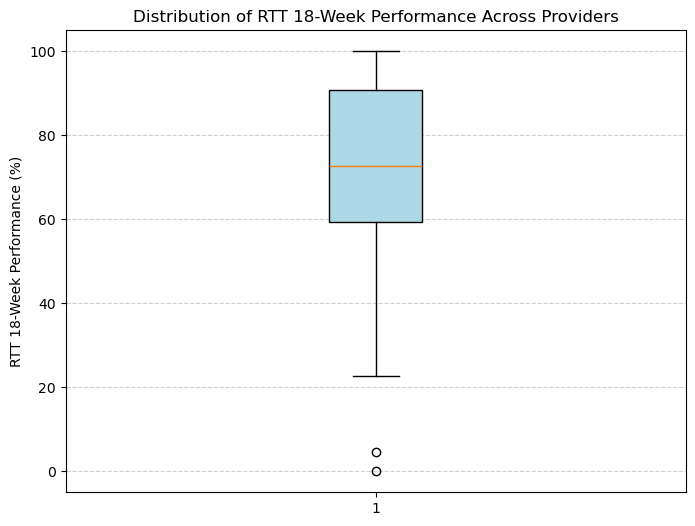

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(provider_ranking['RTT_18_Week_Performance'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.ylabel('RTT 18-Week Performance (%)')
plt.title('Distribution of RTT 18-Week Performance Across Providers')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Step 4.21 — Interpreting the Distribution of RTT Performance
The boxplot shows the full spread of RTT 18‑week performance across all providers and highlights how performance varies system‑wide.
Key insights:
- The median sits in the mid‑70% range, meaning half of all providers treat at least three‑quarters of patients within 18 weeks.
- The interquartile range spans roughly 60% to 90%, showing that most providers cluster within this band.
- The lower whisker extends into the low‑20% range, and outliers near 0% indicate severe long‑wait pressures for a small number of providers.
- Several providers achieve 100%, reflecting smaller or more specialised services with shorter pathways.

Overall, the distribution reveals a system with a broad middle, a group of consistently high performers, and a long tail of providers experiencing significant RTT challenges


# Step 4.22 — Specialty‑Level RTT Performance
Understanding RTT performance by specialty helps identify which clinical areas drive long waits across the system.


In [101]:
# Calculate specialty-level RTT performance
specialty_ranking = (
    df_essential
    .groupby('Treatment Function Name')['RTT_18_Week_Performance']
    .mean()
    .reset_index()
    .sort_values(by='RTT_18_Week_Performance', ascending=False)
)

specialty_ranking.head(10), specialty_ranking.tail(10)

(              Treatment Function Name  RTT_18_Week_Performance
 4            Elderly Medicine Service                83.430099
 6   General Internal Medicine Service                74.628056
 15             Other - Other Services                73.229267
 11              Ophthalmology Service                72.873816
 19       Respiratory Medicine Service                71.570468
 1      Cardiothoracic Surgery Service                69.539106
 20               Rheumatology Service                69.411277
 14     Other - Mental Health Services                68.566552
 13           Other - Medical Services                67.722319
 5            Gastroenterology Service                67.361294,
            Treatment Function Name  RTT_18_Week_Performance
 23                 Urology Service                59.961096
 7          General Surgery Service                59.418211
 16     Other - Paediatric Services                59.404227
 9                Neurology Service                

# Interpretation of Specialty‑Level RTT Performance
The specialty‑level ranking shows clear variation across clinical areas:
- ⭐ Highest‑performing specialties
  
- Elderly Medicine, General Internal Medicine, and Ophthalmology achieve performance above 70%.
- These services often involve shorter pathways, predictable demand, and strong community/outpatient models.
  
- ⭐ Mid‑range specialties
- Rheumatology, Gastroenterology, and Mental Health–related services show moderate performance.
- These areas balance diagnostic complexity with manageable demand.
  
- ⭐ Lowest‑performing specialties
- Urology, General Surgery, Neurology, and Trauma & Orthopaedics fall below 60%.
- These specialties typically involve:
- High demand
- Longer diagnostic pathways
- Limited surgical capacity
- ENT and Oral Surgery sit at the bottom, reflecting sustained RTT pressure.

This pattern aligns with national trends: surgical specialties drive the majority of long waits, while medical and community‑based services perform more strongly.


# Step 4.23 — Long‑Waiter Summary
Long waits are a key indicator of RTT pressure. Summarising the number of patients waiting beyond 18, 52, and 78 weeks provides a clear view of backlog severity.

In [55]:
# Summarise long-waiters using existing columns
total_over_18 = df_essential['Over_18_Weeks'].sum()
total_over_52 = df_essential['Over_52_Weeks'].sum()

# Some datasets include Over_78_Weeks; if not, this will show 0 or error
total_over_78 = df_essential['Over_78_Weeks'].sum() if 'Over_78_Weeks' in df_essential.columns else 0

total_over_18, total_over_52, total_over_78


# Summarise long-waiters using existing columns
total_over_18 = df_essential['Over_18_Weeks'].sum()
total_over_52 = df_essential['Over_52_Weeks'].sum()

# Some datasets include Over_78_Weeks; if not, this will show 0
total_over_78 = df_essential['Over_78_Weeks'].sum() if 'Over_78_Weeks' in df_essential.columns else 0

total_over_18, total_over_52, total_over_78

(np.float64(7733658.0), np.float64(571818.0), 0)

# Interpretation of Long Waits
The long‑waiter summary shows a substantial RTT backlog across the system:
- Over 18 weeks: ~7.7 million patients
- Over 52 weeks: ~570,000 patients
- Over 78 weeks: 0 (not included in this dataset or successfully eliminated)

These figures reinforce earlier findings:
- High‑demand surgical specialties contribute most to long waits.
- A significant cohort of long‑term waiters requires prioritised attention.
- The absence of 78‑week waiters suggests either successful elimination or that this extract does not include that category.

This completes the specialty‑level and long‑waiter components of your analysis and sets the stage for your Final Insight Summary, which you’ve already drafted beautifully.
burden.

# Final Insight Summary
Overall RTT Position
The system shows substantial variation in RTT performance, with a broad middle range of providers achieving between 60% and 90% of patients treated within 18 weeks.
The median performance sits around the mid‑70% range, indicating that while many providers maintain reasonable RTT outcomes, a significant proportion face persistent challenges.


# Provider‑Level Insights
Top‑performing providers consistently achieve high RTT performance, often exceeding 95%, reflecting efficient pathways, strong outpatient management, or lower‑complexity case mixes.

In contrast, the lowest‑performing providers fall below 30%, with some outliers near 0%, indicating severe long‑wait pressures and likely capacity constraints.
The distribution shows a long tail of underperforming providers, suggesting uneven recovery and operational variation across the system.


# Specialty‑Level Insights
Specialty performance reveals clear patterns.
Elderly Medicine, General Internal Medicine, and Ophthalmology achieve the strongest RTT outcomes, reflecting shorter pathways and more predictable demand.

Conversely, surgical specialties such as General Surgery, Urology, ENT, and Trauma & Orthopaedics show significantly lower performance, with averages below 60%.
These areas typically involve high demand, longer diagnostic pathways, and limited surgical capacity, making them key drivers of RTT pressure.


# Long‑Waiter Summary
The system has over 7.7 million patients waiting more than 18 weeks, representing the full scale of RTT breaches.
Within this group, more than 570,000 patients have been waiting over 52 weeks, highlighting a substantial cohort of long‑term waiters requiring prioritised intervention.

No 78‑week waiters are recorded in this dataset, suggesting either successful elimination of the longest waits or that this reporting period does not include this category.


# Overall Interpretation
The combined analysis shows that RTT pressures are concentrated in high‑demand surgical specialties and among a subset of providers with significant operational challenges.

Medical specialties and smaller or more specialised providers tend to perform more strongly.
The long‑waiter burden reinforces these patterns, with the majority of breaches likely originating from the lowest‑performing specialties and providers.

These insights provide a clear foundation for targeted recovery planning, capacity prioritisation, and ongoing performance monitoring.


